In [1]:
!pip install -q langchain langchain-google-genai pandas pydantic

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 67.6/67.6 kB 2.6 MB/s eta 0:00:00


In [2]:
import json
import pandas as pd

from pydantic import BaseModel
from langchain_google_genai import ChatGoogleGenerativeAI

In [3]:
class StudentRecord(BaseModel):
    student_id: str
    student_name: str
    age: int
    gender: str
    course: str
    year_of_study: int
    attendance_percentage: float
    assignment_score: float
    internal_marks: float
    exam_score: float
    study_hours_per_day: int
    extracurricular_activity: str
    internet_usage_hours: float
    final_grade: str
    pass_fail_status: str

In [5]:
GOOGLE_API_KEY = "your_api_key"

In [6]:
llm = ChatGoogleGenerativeAI(
    model="gemini-2.5-flash",
    google_api_key=GOOGLE_API_KEY,
    temperature=1
)

In [7]:
prompt = """
Generate 20 realistic synthetic student performance records.

Fields:
student_id
student_name
age
gender
course
year_of_study
attendance_percentage
assignment_score
internal_marks
exam_score
study_hours_per_day
extracurricular_activity
internet_usage_hours
final_grade
pass_fail_status

Rules:
- Include students with different performance levels
- Include toppers, average students, and failing students
- Attendance should affect grades realistically
- Return ONLY valid JSON array
"""

In [9]:
response = llm.invoke(prompt)

In [10]:
clean_text = response.content.strip()

clean_text = clean_text.replace("```json", "")
clean_text = clean_text.replace("```", "")

In [11]:
data = json.loads(clean_text)

In [12]:
df = pd.DataFrame(data)

In [13]:
print(df.head())

  student_id student_name  age  gender                   course  \
0       S001       Oliver   22    Male   Mechanical Engineering   
1       S002          Mia   20  Female               Psychology   
2       S003       Evelyn   21  Female         Computer Science   
3       S004         Liam   19    Male   Electrical Engineering   
4       S005     Isabella   20  Female  Business Administration   

   year_of_study  attendance_percentage  assignment_score  internal_marks  \
0              3                     94                90              95   
1              2                     78                75              80   
2              3                     58                45              38   
3              1                     85                88              82   
4              2                     65                58              52   

   exam_score  study_hours_per_day extracurricular_activity  \
0          92                    6              Coding Club   
1       

In [14]:
df.to_csv("student_dataset.csv", index=False)

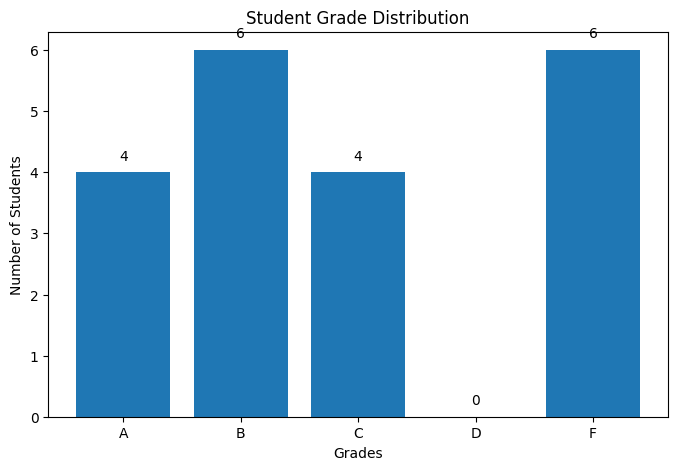

In [16]:
import matplotlib.pyplot as plt

# Count number of students in each grade
grade_counts = df["final_grade"].value_counts()

# Arrange grades in proper order
grade_order = ["A", "B", "C", "D", "F"]

# Reorder counts based on grade order
grade_counts = grade_counts.reindex(grade_order, fill_value=0)

# Create bar chart
plt.figure(figsize=(8,5))

plt.bar(grade_counts.index, grade_counts.values)

# Chart title
plt.title("Student Grade Distribution")

# X-axis label
plt.xlabel("Grades")

# Y-axis label
plt.ylabel("Number of Students")

# Show values on bars
for i, value in enumerate(grade_counts.values):
    plt.text(i, value + 0.2, str(value), ha='center')

# Display graph
plt.show()